# <span style="font-width:bold; font-size: 3rem; color:#1EB182;"> **Air Quality** </span><span style="font-width:bold; font-size: 3rem; color:#333;">- Part 04: Batch Inference</span>

## 🗒️ This notebook is divided into the following sections:

1. Download model and batch inference data
2. Make predictions, generate PNG for forecast
3. Store predictions in a monitoring feature group adn generate PNG for hindcast

## <span style='color:#ff5f27'> 📝 Imports

In [1]:
import sys
from pathlib import Path

def is_google_colab() -> bool:
    if "google.colab" in str(get_ipython()):
        return True
    return False

def clone_repository() -> None:
    !git clone https://github.com/featurestorebook/mlfs-book.git
    %cd mlfs-book

def install_dependencies() -> None:
    !pip install --upgrade uv
    !uv pip install --all-extras --system --requirement pyproject.toml


if is_google_colab():
    clone_repository()
    install_dependencies()
    root_dir = str(Path().absolute())
    print("Google Colab environment")
else:
    root_dir = Path().absolute()
    # Strip ~/notebooks/ccfraud from PYTHON_PATH if notebook started in one of these subdirectories
    if root_dir.parts[-1:] == ('airquality',):
        root_dir = Path(*root_dir.parts[:-1])
    if root_dir.parts[-1:] == ('notebooks',):
        root_dir = Path(*root_dir.parts[:-1])
    root_dir = str(root_dir) 
    print("Local environment")

# Add the root directory to the `PYTHONPATH` to use the `recsys` Python module from the notebook.
if root_dir not in sys.path:
    sys.path.append(root_dir)
print(f"Added the following directory to the PYTHONPATH: {root_dir}")
    
# Read the API keys and configuration variables from the file <root_dir>/.env
from mlfs import config
#settings = config.HopsworksSettings(_env_file=f"{root_dir}/.env")

Local environment
Added the following directory to the PYTHONPATH: /Users/edvinramstrom/Documents/KTH/ID2223 Scalable/mlfs-book


In [2]:
import datetime
import pandas as pd
from xgboost import XGBRegressor
import hopsworks
import json
from mlfs.airquality import util
import os

### <span style='color:#ff5f27'> 🎯 Sensor Configuration</span>

**Change the sensor street name below to select which sensor to run inference for:**

In [3]:
# === SENSOR SELECTION - SET THIS PARAMETER ===
# This can be set via papermill: papermill input.ipynb output.ipynb -p SENSOR_STREET "arnulf-klett-platz"
SENSOR_STREET = "bad-cannstatt"  # Options: "arnulf-klett-platz", "am-neckartor"

print(f"Running inference for sensor: {SENSOR_STREET}")

Running inference for sensor: bad-cannstatt


In [4]:
today = datetime.datetime.now() - datetime.timedelta(0)
tomorrow = today + datetime.timedelta(days = 1)
today

datetime.datetime(2025, 11, 18, 22, 50, 57, 850022)

## <span style="color:#ff5f27;"> 📡 Connect to Hopsworks Feature Store </span>

In [5]:
project = hopsworks.login(engine="python")
fs = project.get_feature_store() 

secrets = hopsworks.get_secrets_api()

# Load sensor-specific configuration from Hopsworks secret
secret_name = f"SENSOR_LOCATION_JSON_{SENSOR_STREET.upper().replace('-', '_')}"
location_str = secrets.get_secret(secret_name).value
location = json.loads(location_str)

country=location['country']
city=location['city']
street=location['street']

print(f"Loaded configuration for sensor: {street}")

2025-11-18 22:50:57,859 INFO: Initializing external client
2025-11-18 22:50:57,860 INFO: Base URL: https://c.app.hopsworks.ai:443
2025-11-18 22:50:58,520 WARNING: UserWarning: The installed hopsworks client version 4.4.2 may not be compatible with the connected Hopsworks backend version 4.2.2. 
To ensure compatibility please install the latest bug fix release matching the minor version of your backend (4.2) by running 'pip install hopsworks==4.2.*'



2025-11-18 22:50:59,620 INFO: Python Engine initialized.

Logged in to project, explore it here https://c.app.hopsworks.ai:443/p/1298581
Loaded configuration for sensor: bad-cannstatt


## <span style="color:#ff5f27;">🪝 Download the model from Model Registry</span>

In [6]:
mr = project.get_model_registry()

# Get sensor-specific model
model_name = f"air_quality_xgboost_model_{street.replace('-', '_')}"
print(f"Loading model: {model_name}")

retrieved_model = mr.get_model(
    name=model_name,
    version=1,
)

fv = retrieved_model.get_feature_view()

# Download the saved model artifacts to a local directory
saved_model_dir = retrieved_model.download()

Loading model: air_quality_xgboost_model_bad_cannstatt
2025-11-18 22:51:04,470 INFO: Initializing for batch retrieval of feature vectors


Downloading: 0.000%|          | 0/569109 elapsed<00:00 remaining<?

Downloading: 0.000%|          | 0/144807 elapsed<00:00 remaining<?

Downloading: 0.000%|          | 0/32822 elapsed<00:00 remaining<?

In [7]:
# Loading the XGBoost regressor model and label encoder from the saved model directory
# retrieved_xgboost_model = joblib.load(saved_model_dir + "/xgboost_regressor.pkl")
retrieved_xgboost_model = XGBRegressor()

retrieved_xgboost_model.load_model(saved_model_dir + "/model.json")

# Displaying the retrieved XGBoost regressor model
retrieved_xgboost_model

XGBRegressor(base_score='3.857072E1', booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None,
             feature_types=['float', 'float', 'float', 'int', 'float', 'float',
                            'float', 'float', 'float', 'float'],
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

## <span style="color:#ff5f27;">✨ Get Weather Forecast Features with Feature View   </span>



In [8]:
air_quality_fg = fs.get_feature_group(
    name='air_quality',
    version=3,
)
weather_fg = fs.get_feature_group(
    name='weather',
    version=2,
)
batch_data = weather_fg.filter(weather_fg.date >= today).read()
batch_data

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (0.70s) 


,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,relative_humidity_2m_mean,surface_pressure_mean,city
0,2025-11-19 00:00:00+00:00,6.55,0.0,13.797912,187.495758,52.0,978.300903,stuttgart
1,2025-11-20 00:00:00+00:00,2.40,0.1,10.464797,296.564972,79.0,981.057495,stuttgart
2,2025-11-23 00:00:00+00:00,0.15,0.0,7.771331,103.392517,51.0,979.647400,stuttgart
3,2025-11-22 00:00:00+00:00,-0.45,0.0,2.276840,341.564941,69.0,995.383484,stuttgart
4,2025-11-21 00:00:00+00:00,1.65,0.0,12.682018,6.519707,83.0,989.024353,stuttgart
5,2025-11-24 00:00:00+00:00,4.50,0.1,12.387348,215.537766,84.0,971.584167,stuttgart


In [9]:
# Get the last 3 days
lag_features = util.get_pm25_lagged_features(air_quality_fg, today, country, city, street)
print(f"Starting lagged features: {lag_features}")

# Add initial lagged features to the first row of batch data
batch_data = batch_data.sort_values('date').reset_index(drop=True)
batch_data['pm25_lag1'] = None
batch_data['pm25_lag2'] = None
batch_data['pm25_lag3'] = None

# Set the initial lagged values for the first prediction
batch_data.loc[0, 'pm25_lag1'] = lag_features['pm25_lag1']
batch_data.loc[0, 'pm25_lag2'] = lag_features['pm25_lag2']
batch_data.loc[0, 'pm25_lag3'] = lag_features['pm25_lag3']

batch_data['pm25_lag1'] = batch_data['pm25_lag1'].astype('float32')
batch_data['pm25_lag2'] = batch_data['pm25_lag2'].astype('float32')
batch_data['pm25_lag3'] = batch_data['pm25_lag3'].astype('float32')

# Day of week feature
batch_data['day_of_week'] = batch_data['date'].dt.dayofweek

batch_data['day_of_week'] = batch_data['day_of_week'].astype('int32')


batch_data

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (0.69s) 
Starting lagged features: {'pm25_lag1': 28.0, 'pm25_lag2': 53.0, 'pm25_lag3': 63.0}


,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,relative_humidity_2m_mean,surface_pressure_mean,city,pm25_lag1,pm25_lag2,pm25_lag3,day_of_week
0,2025-11-19 00:00:00+00:00,6.55,0.0,13.797912,187.495758,52.0,978.300903,stuttgart,28.0,53.0,63.0,2
1,2025-11-20 00:00:00+00:00,2.40,0.1,10.464797,296.564972,79.0,981.057495,stuttgart,NaN,NaN,NaN,3
2,2025-11-21 00:00:00+00:00,1.65,0.0,12.682018,6.519707,83.0,989.024353,stuttgart,NaN,NaN,NaN,4
3,2025-11-22 00:00:00+00:00,-0.45,0.0,2.276840,341.564941,69.0,995.383484,stuttgart,NaN,NaN,NaN,5
4,2025-11-23 00:00:00+00:00,0.15,0.0,7.771331,103.392517,51.0,979.647400,stuttgart,NaN,NaN,NaN,6
5,2025-11-24 00:00:00+00:00,4.50,0.1,12.387348,215.537766,84.0,971.584167,stuttgart,NaN,NaN,NaN,0


In [10]:

predictions = []
# predict each day using loop
for i in range(len(batch_data)):
    # Get current row features
    current_features = batch_data.iloc[[i]][['pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'day_of_week',
                                              'temperature_2m_mean', 'precipitation_sum', 
                                              'wind_speed_10m_max', 'wind_direction_10m_dominant',
                                              'relative_humidity_2m_mean', 'surface_pressure_mean']].copy()

    
    # Make prediction
    pred = retrieved_xgboost_model.predict(current_features)[0]
    predictions.append(pred)

    # Update lagged features for subsequent predictions
    if i + 1 < len(batch_data):
        batch_data.loc[i + 1, 'pm25_lag1'] = pred
        batch_data.loc[i + 1, 'pm25_lag2'] = batch_data.loc[i, 'pm25_lag1']
        batch_data.loc[i + 1, 'pm25_lag3'] = batch_data.loc[i, 'pm25_lag2']

batch_data['predicted_pm25'] = predictions
batch_data


,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,relative_humidity_2m_mean,surface_pressure_mean,city,pm25_lag1,pm25_lag2,pm25_lag3,day_of_week,predicted_pm25
0,2025-11-19 00:00:00+00:00,6.55,0.0,13.797912,187.495758,52.0,978.300903,stuttgart,28.000000,53.000000,63.000000,2,28.993687
1,2025-11-20 00:00:00+00:00,2.40,0.1,10.464797,296.564972,79.0,981.057495,stuttgart,28.993687,28.000000,53.000000,3,30.636581
2,2025-11-21 00:00:00+00:00,1.65,0.0,12.682018,6.519707,83.0,989.024353,stuttgart,30.636581,28.993687,28.000000,4,46.267902
3,2025-11-22 00:00:00+00:00,-0.45,0.0,2.276840,341.564941,69.0,995.383484,stuttgart,46.267902,30.636581,28.993687,5,62.338654
4,2025-11-23 00:00:00+00:00,0.15,0.0,7.771331,103.392517,51.0,979.647400,stuttgart,62.338654,46.267902,30.636581,6,70.351387
5,2025-11-24 00:00:00+00:00,4.50,0.1,12.387348,215.537766,84.0,971.584167,stuttgart,70.351387,62.338654,46.267902,0,56.475071


In [11]:
batch_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype                  
---  ------                       --------------  -----                  
 0   date                         6 non-null      datetime64[us, Etc/UTC]
 1   temperature_2m_mean          6 non-null      float32                
 2   precipitation_sum            6 non-null      float32                
 3   wind_speed_10m_max           6 non-null      float32                
 4   wind_direction_10m_dominant  6 non-null      float32                
 5   relative_humidity_2m_mean    6 non-null      float32                
 6   surface_pressure_mean        6 non-null      float32                
 7   city                         6 non-null      object                 
 8   pm25_lag1                    6 non-null      float32                
 9   pm25_lag2                    6 non-null      float32                
 10  pm25_l

### <span style="color:#ff5f27;">🤖 Saving the predictions (for monitoring) to a Feature Group</span>

In [12]:
# Drop lagged features before saving to monitoring feature group
batch_data_monitor = batch_data

batch_data_monitor['street'] = street
batch_data_monitor['city'] = city
batch_data_monitor['country'] = country
# Fill in the number of days before the date on which you made the forecast (base_date)
batch_data_monitor['days_before_forecast_day'] = range(1, len(batch_data_monitor)+1)
batch_data_monitor = batch_data_monitor.sort_values(by=['date'])
batch_data_monitor

,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,relative_humidity_2m_mean,surface_pressure_mean,city,pm25_lag1,pm25_lag2,pm25_lag3,day_of_week,predicted_pm25,street,country,days_before_forecast_day
0,2025-11-19 00:00:00+00:00,6.55,0.0,13.797912,187.495758,52.0,978.300903,stuttgart,28.000000,53.000000,63.000000,2,28.993687,bad-cannstatt,germany,1
1,2025-11-20 00:00:00+00:00,2.40,0.1,10.464797,296.564972,79.0,981.057495,stuttgart,28.993687,28.000000,53.000000,3,30.636581,bad-cannstatt,germany,2
2,2025-11-21 00:00:00+00:00,1.65,0.0,12.682018,6.519707,83.0,989.024353,stuttgart,30.636581,28.993687,28.000000,4,46.267902,bad-cannstatt,germany,3
3,2025-11-22 00:00:00+00:00,-0.45,0.0,2.276840,341.564941,69.0,995.383484,stuttgart,46.267902,30.636581,28.993687,5,62.338654,bad-cannstatt,germany,4
4,2025-11-23 00:00:00+00:00,0.15,0.0,7.771331,103.392517,51.0,979.647400,stuttgart,62.338654,46.267902,30.636581,6,70.351387,bad-cannstatt,germany,5
5,2025-11-24 00:00:00+00:00,4.50,0.1,12.387348,215.537766,84.0,971.584167,stuttgart,70.351387,62.338654,46.267902,0,56.475071,bad-cannstatt,germany,6


In [13]:
batch_data_monitor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype                  
---  ------                       --------------  -----                  
 0   date                         6 non-null      datetime64[us, Etc/UTC]
 1   temperature_2m_mean          6 non-null      float32                
 2   precipitation_sum            6 non-null      float32                
 3   wind_speed_10m_max           6 non-null      float32                
 4   wind_direction_10m_dominant  6 non-null      float32                
 5   relative_humidity_2m_mean    6 non-null      float32                
 6   surface_pressure_mean        6 non-null      float32                
 7   city                         6 non-null      object                 
 8   pm25_lag1                    6 non-null      float32                
 9   pm25_lag2                    6 non-null      float32                
 10  pm25_l

### Create Forecast Graph
Draw a graph of the predictions with dates as a PNG and save it to the github repo
Show it on github pages

2025-11-18 22:51:13,159 WARNING: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.



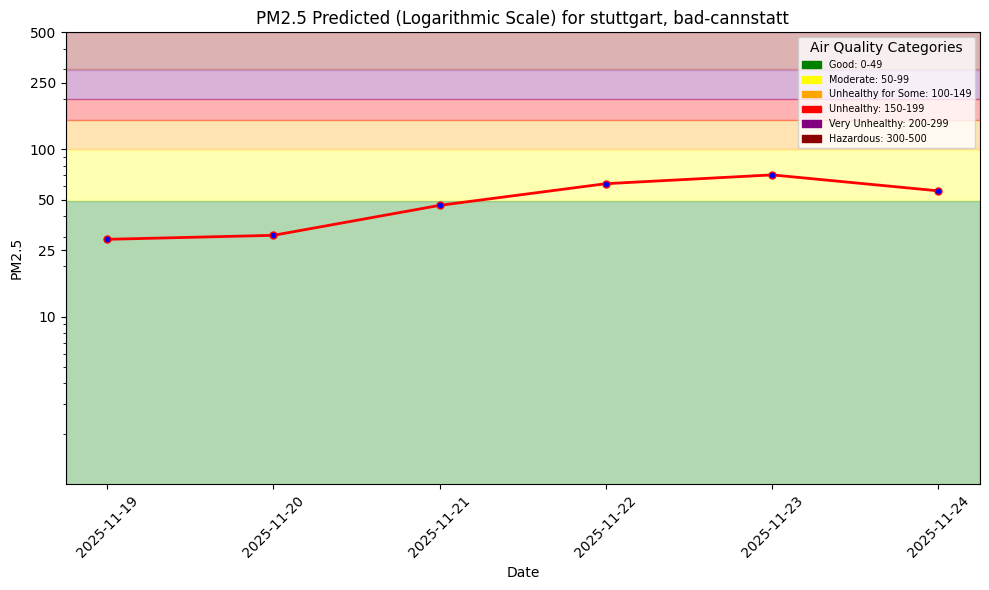

In [14]:
pred_file_path = f"{root_dir}/docs/air-quality/assets/img/pm25_forecast_{street}.png"
plt = util.plot_air_quality_forecast(city, street, batch_data_monitor, pred_file_path)

plt.show()

In [15]:
# Get or create feature group
monitor_fg = fs.get_or_create_feature_group(
    name='aq_predictions',
    description='Air Quality prediction monitoring',
    version=3,
    primary_key=['city','street','date','days_before_forecast_day'],
    event_time="date"
)

In [16]:
monitor_fg.insert(batch_data_monitor, wait=True)

Uploading Dataframe: 100.00% |██████████| Rows 6/6 | Elapsed Time: 00:01 | Remaining Time: 00:00


Launching job: aq_predictions_3_offline_fg_materialization
Job started successfully, you can follow the progress at 
https://c.app.hopsworks.ai:443/p/1298581/jobs/named/aq_predictions_3_offline_fg_materialization/executions
2025-11-18 22:51:31,017 INFO: Waiting for execution to finish. Current state: SUBMITTED. Final status: UNDEFINED
2025-11-18 22:51:37,514 INFO: Waiting for execution to finish. Current state: RUNNING. Final status: UNDEFINED
2025-11-18 22:53:24,725 INFO: Waiting for execution to finish. Current state: AGGREGATING_LOGS. Final status: SUCCEEDED
2025-11-18 22:53:24,890 INFO: Waiting for log aggregation to finish.
2025-11-18 22:53:33,522 INFO: Execution finished successfully.


(Job('aq_predictions_3_offline_fg_materialization', 'SPARK'), None)

In [17]:
# We will create a hindcast chart for  only the forecasts made 1 day beforehand
monitoring_df = monitor_fg.filter(monitor_fg.days_before_forecast_day == 1).read()
monitoring_df

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.19s) 


,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,relative_humidity_2m_mean,surface_pressure_mean,city,pm25_lag1,pm25_lag2,pm25_lag3,day_of_week,predicted_pm25,street,country,days_before_forecast_day
0,2025-11-14 00:00:00+00:00,16.549999,0.000000,3.617955,95.710503,55.000000,981.800659,stuttgart,51.0,49.0,52.0,4,46.448978,arnulf-klett-platz,germany,1
1,2025-11-18 00:00:00+00:00,4.100000,0.000000,2.968636,165.963730,73.000000,990.941345,stuttgart,NaN,NaN,NaN,1,117.667999,arnulf-klett-platz,germany,1
2,2025-11-18 00:00:00+00:00,4.100000,0.000000,2.968636,165.963730,73.000000,990.941345,stuttgart,NaN,NaN,NaN,1,117.667999,stuttgart-am-neckartor,germany,1
3,2025-11-19 00:00:00+00:00,6.550000,0.000000,13.797912,187.495758,52.000000,978.300903,stuttgart,29.0,58.0,77.0,2,39.330360,arnulf-klett-platz,germany,1
4,2025-11-19 00:00:00+00:00,6.550000,0.000000,13.797912,187.495758,52.000000,978.300903,stuttgart,28.0,53.0,66.0,2,33.736801,am-neckartor,germany,1
5,2025-11-19 00:00:00+00:00,6.550000,0.000000,13.797912,187.495758,52.000000,978.300903,stuttgart,28.0,53.0,63.0,2,28.993687,bad-cannstatt,germany,1
6,2025-11-19 00:00:00+00:00,6.550000,0.000000,13.797912,187.495758,52.000000,978.300903,stuttgart,33.0,52.0,63.0,2,33.519688,ludwigsburg,germany,1
7,2025-11-19 00:00:00+00:00,6.550000,0.000000,13.797912,187.495758,52.000000,978.300903,stuttgart,22.0,43.0,66.0,2,31.048763,bernhausen,germany,1
8,2025-11-18 00:00:00+00:00,4.100000,0.000000,2.968636,165.963730,73.000000,990.941345,stuttgart,NaN,NaN,NaN,1,117.667999,ludwigsburg,germany,1
9,2025-11-17 00:00:00+00:00,5.120417,7.299999,21.332088,305.130859,92.015144,982.453369,stuttgart,NaN,NaN,NaN,0,88.372780,bernhausen,germany,1


In [18]:
air_quality_fg = fs.get_feature_group(name='air_quality', version=3)
air_quality_df = air_quality_fg.read()
air_quality_df

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.41s) 


,date,pm25,pm25_lag1,pm25_lag2,pm25_lag3,day_of_week,country,city,street,url
0,2021-01-10 00:00:00+00:00,58.0,46.0,38.0,30.0,6,germany,stuttgart,arnulf-klett-platz,https://api.waqi.info/feed/@11226
1,2024-02-25 00:00:00+00:00,29.0,24.0,17.0,26.0,6,germany,stuttgart,arnulf-klett-platz,https://api.waqi.info/feed/@11226
2,2020-01-11 00:00:00+00:00,29.0,36.0,56.0,57.0,5,germany,stuttgart,arnulf-klett-platz,https://api.waqi.info/feed/@11226
3,2022-02-22 00:00:00+00:00,25.0,17.0,22.0,26.0,1,germany,stuttgart,arnulf-klett-platz,https://api.waqi.info/feed/@11226
4,2022-07-26 00:00:00+00:00,37.0,58.0,56.0,52.0,1,germany,stuttgart,arnulf-klett-platz,https://api.waqi.info/feed/@11226
...,...,...,...,...,...,...,...,...,...,...
15206,2025-09-11 00:00:00+00:00,17.0,20.0,46.0,26.0,3,germany,stuttgart,bernhausen,https://api.waqi.info/feed/@6154
15207,2022-12-09 00:00:00+00:00,59.0,42.0,37.0,46.0,4,germany,stuttgart,bernhausen,https://api.waqi.info/feed/@6154
15208,2023-10-17 00:00:00+00:00,34.0,21.0,17.0,32.0,1,germany,stuttgart,bernhausen,https://api.waqi.info/feed/@6154
15209,2022-07-08 00:00:00+00:00,17.0,24.0,24.0,23.0,4,germany,stuttgart,bernhausen,https://api.waqi.info/feed/@6154


In [19]:
outcome_df = air_quality_df[['date', 'pm25', 'city', 'street']]
preds_df =  monitoring_df[['date', 'predicted_pm25', 'city', 'street']]

hindcast_df = pd.merge(preds_df, outcome_df, on=["date", "city", "street"])
hindcast_df = hindcast_df.sort_values(by=['date'])
# filter by street
hindcast_df = hindcast_df[hindcast_df['street'] == street]

# If there are no outcomes for predictions yet, generate some predictions/outcomes from existing data
if len(hindcast_df) == 0:
    air_quality_filtered = air_quality_df[air_quality_df['street'] == street].copy()
    print("No outcomes for predictions yet, generating some predictions/outcomes from existing data")
    hindcast_df = util.backfill_predictions_for_monitoring(weather_fg, air_quality_filtered, monitor_fg, retrieved_xgboost_model)

hindcast_df

,date,predicted_pm25,city,street,pm25
24,2025-11-09 00:00:00+00:00,71.348686,stuttgart,bad-cannstatt,62.0
20,2025-11-10 00:00:00+00:00,59.187561,stuttgart,bad-cannstatt,49.0
22,2025-11-11 00:00:00+00:00,41.152985,stuttgart,bad-cannstatt,37.0
25,2025-11-12 00:00:00+00:00,47.467091,stuttgart,bad-cannstatt,47.0
21,2025-11-13 00:00:00+00:00,51.338844,stuttgart,bad-cannstatt,54.0
23,2025-11-14 00:00:00+00:00,49.800087,stuttgart,bad-cannstatt,56.0
19,2025-11-15 00:00:00+00:00,41.958736,stuttgart,bad-cannstatt,63.0
12,2025-11-16 00:00:00+00:00,61.166874,stuttgart,bad-cannstatt,53.0
17,2025-11-17 00:00:00+00:00,23.067814,stuttgart,bad-cannstatt,28.0
11,2025-11-18 00:00:00+00:00,36.508732,stuttgart,bad-cannstatt,34.0


### Plot the Hindcast comparing predicted with forecasted values (1-day prior forecast)

__This graph will be empty to begin with - this is normal.__

After a few days of predictions and observations, you will get data points in this graph.

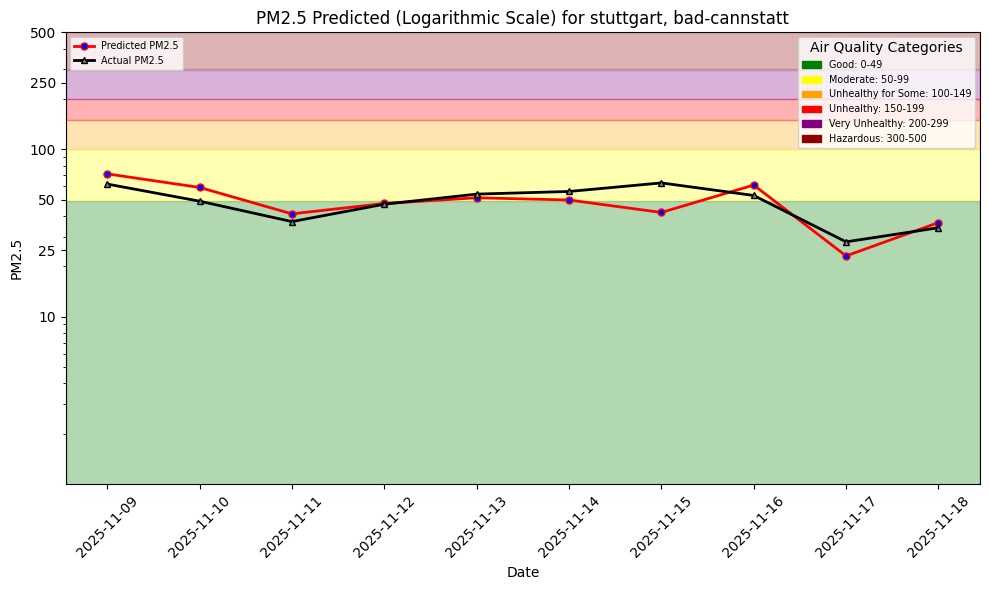

In [20]:
hindcast_file_path = f"{root_dir}/docs/air-quality/assets/img/pm25_hindcast_1day_{street}.png"
plt = util.plot_air_quality_forecast(city, street, hindcast_df, hindcast_file_path, hindcast=True)
plt.show()

### Upload the prediction and hindcast dashboards (png files) to Hopsworks


In [21]:
dataset_api = project.get_dataset_api()
str_today = today.strftime("%Y-%m-%d")
if dataset_api.exists("Resources/airquality") == False:
    dataset_api.mkdir("Resources/airquality")
dataset_api.upload(pred_file_path, f"Resources/airquality/{city}_{street}_{str_today}", overwrite=True)
dataset_api.upload(hindcast_file_path, f"Resources/airquality/{city}_{street}_{str_today}", overwrite=True)

proj_url = project.get_url()
print(f"See images in Hopsworks here: {proj_url}/settings/fb/path/Resources/airquality")

Uploading /Users/edvinramstrom/Documents/KTH/ID2223 Scalable/mlfs-book/docs/air-quality/assets/img/pm25_foreca…

Uploading /Users/edvinramstrom/Documents/KTH/ID2223 Scalable/mlfs-book/docs/air-quality/assets/img/pm25_hindca…

See images in Hopsworks here: https://c.app.hopsworks.ai:443/p/1298581/settings/fb/path/Resources/airquality


---